## Project Summary

This project, **College Event Feedback Analysis**, aimed to uncover student satisfaction trends and improvement areas from survey data collected after campus events or courses. Using Python tools like **pandas**, **seaborn**, and **NLTK’s VADER**, the analysis explored numeric ratings, visualized satisfaction patterns, and performed sentiment analysis on textual feedback. The insights drawn help institutions understand how students perceive event quality, teaching effectiveness, and overall experience — guiding data-driven decisions to enhance future academic and social activities.


##1.Installing and Importing Libraries

This cell installs and imports the essential libraries needed for data analysis and visualization.
pandas handles data manipulation, matplotlib and seaborn create charts, and nltk (with vader_lexicon) enables sentiment analysis using the VADER tool.

In [2]:
# Install libraries (only run once)
!pip install pandas matplotlib seaborn nltk

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

##2.Uploading and Loading the Dataset

This cell allows you to upload your CSV file directly into Google Colab and read it into a pandas DataFrame.
It first tries to load the file using UTF-8 encoding, but if that fails (common with Excel files), it switches to `latin1`. The first few rows are then displayed to confirm successful loading.


In [6]:
from google.colab import files
uploaded = files.upload()

# Get the uploaded file name dynamically
filename = next(iter(uploaded))

# Try reading with utf-8 first, then fallback to 'latin1' if needed
try:
    df = pd.read_csv(filename, encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(filename, encoding='latin1')

# Show first few rows
df.head()


Saving Student_Satisfaction_Survey.csv to Student_Satisfaction_Survey (3).csv


,SN,Total Feedback Given,Total Configured,Questions,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5,Average/ Percentage,Course Name,Basic Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


##3. Inspecting and Cleaning the Data

This cell displays the structure of the dataset, including column names, data types, and non-null counts.
It then checks for missing values, removes any rows where the “Questions” column is empty (since it’s important for analysis), resets the index, and finally shows a clean preview of the data.


In [7]:
# Basic info
df.info()

# Check for missing values
print("\nMissing values per column:\n", df.isna().sum())

# Drop empty rows in important columns
df.dropna(subset=['Questions'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Show a preview
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   SN                    580 non-null    int64 
 1   Total Feedback Given  580 non-null    int64 
 2   Total Configured      580 non-null    int64 
 3   Questions             580 non-null    object
 4   Weightage 1           580 non-null    int64 
 5   Weightage 2           580 non-null    int64 
 6   Weightage 3           580 non-null    int64 
 7   Weightage 4           580 non-null    int64 
 8   Weightage 5           580 non-null    int64 
 9   Average/ Percentage   580 non-null    object
 10  Course Name           580 non-null    object
 11  Basic Course          580 non-null    object
dtypes: int64(8), object(4)
memory usage: 54.5+ KB

Missing values per column:
 SN                      0
Total Feedback Given    0
Total Configured        0
Questions               0
Weightage 1

,SN,Total Feedback Given,Total Configured,Questions,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5,Average/ Percentage,Course Name,Basic Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


##4. Exploring Numeric Data

This cell identifies all numeric columns in the dataset and provides summary statistics such as mean, median, and standard deviation.
It then creates histograms to visualize the distribution of these numeric variables, helping you quickly spot patterns or outliers in the feedback data.


In [8]:
# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols].describe()



,SN,Total Feedback Given,Total Configured,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5
count,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000
mean,10.500000,14.310345,92.517241,0.527586,1.187931,2.537931,5.082759,4.974138
std,5.771259,16.488031,114.491780,1.305336,1.686334,3.193302,7.288293,6.494931
min,1.000000,1.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.750000,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,10.500000,7.000000,42.000000,0.000000,0.000000,1.000000,3.000000,3.000000
75%,15.250000,17.000000,123.000000,1.000000,2.000000,3.250000,6.000000,6.000000
max,20.000000,74.000000,559.000000,19.000000,8.000000,26.000000,52.000000,38.000000


<Figure size 1400x800 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


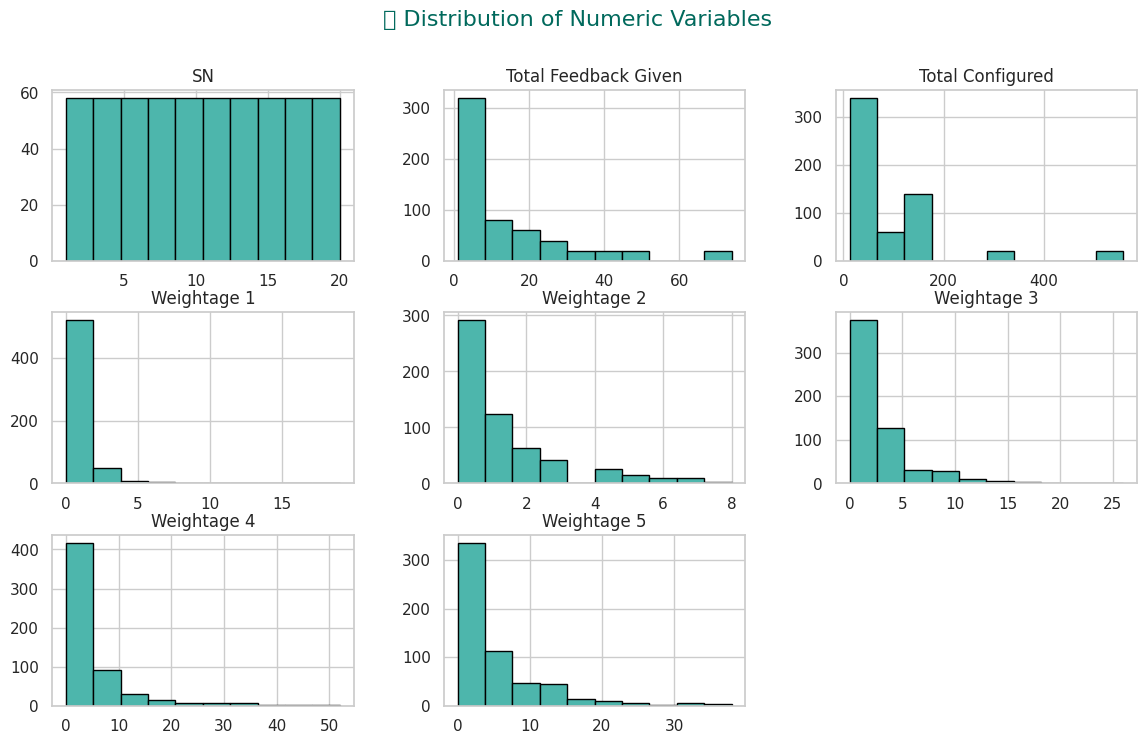

In [9]:
plt.figure(figsize=(14,8))
df[numeric_cols].hist(bins=10, figsize=(14,8), color='#4DB6AC', edgecolor='black')
plt.suptitle("📊 Distribution of Numeric Variables", fontsize=16, color='#00695C')
plt.show()


##5. Analyzing Satisfaction Ratings

This cell focuses on the 1–5 rating scale columns (Weightage and Average/Percentage) to uncover satisfaction patterns.
It converts these columns to numeric form, displays summary statistics, and uses boxplots to visualize score distributions. A bar chart compares average satisfaction across different courses, while a heatmap shows correlations between rating metrics, revealing how various satisfaction measures relate to one another.


 Summary Statistics of Ratings:


,count,mean,std,min,25%,50%,75%,max
Weightage 1,580.0,0.527586,1.305336,0.0,0.0,0.0,1.00,19.0
Weightage 2,580.0,1.187931,1.686334,0.0,0.0,0.0,2.00,8.0
Weightage 3,580.0,2.537931,3.193302,0.0,0.0,1.0,3.25,26.0
Weightage 4,580.0,5.082759,7.288293,0.0,1.0,3.0,6.00,52.0
Weightage 5,580.0,4.974138,6.494931,0.0,1.0,3.0,6.00,38.0
Average/ Percentage,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


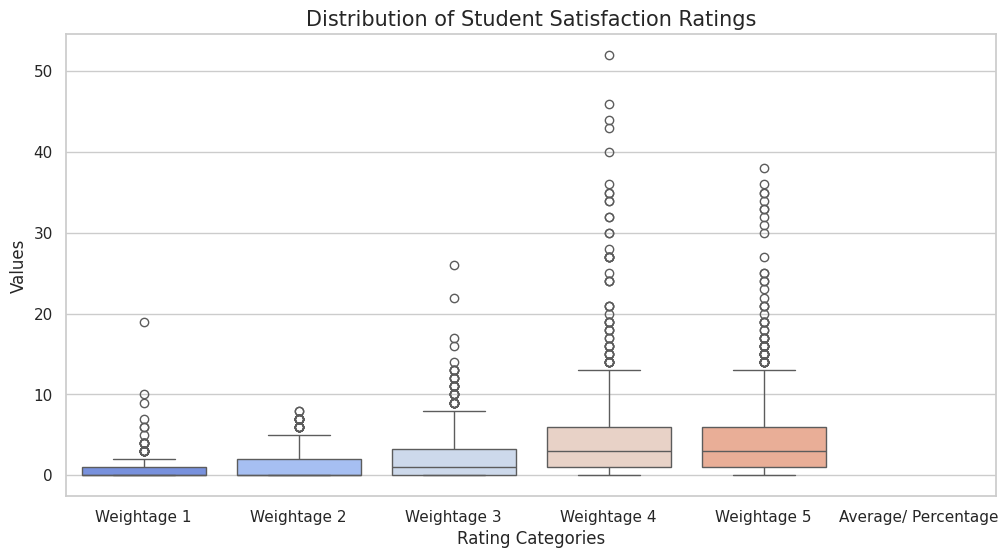

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


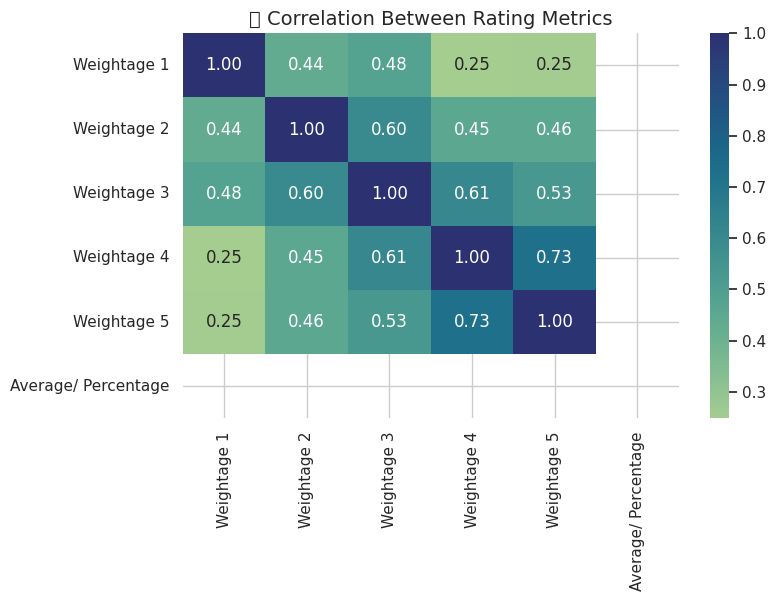

In [13]:

# Analyze Ratings (1–5 Scale)


# Select rating columns (Weightage 1–5 and Average/Percentage)
rating_cols = [col for col in df.columns if 'Weightage' in col or 'Average' in col or 'Percentage' in col]

# Convert to numeric (if not already)
df[rating_cols] = df[rating_cols].apply(pd.to_numeric, errors='coerce')

# Summary statistics
print(" Summary Statistics of Ratings:")
display(df[rating_cols].describe().T)

# Visualize distributions
plt.figure(figsize=(12,6))
sns.boxplot(data=df[rating_cols], palette='coolwarm')
plt.title("Distribution of Student Satisfaction Ratings", fontsize=15)
plt.xlabel("Rating Categories")
plt.ylabel("Values")
plt.show()

# Average satisfaction by course
if 'Course Name' in df.columns:
    course_avg = df.groupby('Course Name')[rating_cols].mean().reset_index()

    plt.figure(figsize=(12,6))
    sns.barplot(data=course_avg, x='Course Name', y='Average/ Percentage', palette='viridis')
    plt.title("🏫 Average Student Satisfaction by Course", fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Correlation between rating measures
plt.figure(figsize=(8,5))
sns.heatmap(df[rating_cols].corr(), annot=True, cmap='crest', fmt=".2f")
plt.title("🔗 Correlation Between Rating Metrics", fontsize=14)
plt.show()


##6. Visualizing Common Phrases with a Word Cloud

This cell generates a colorful word cloud from the text in the “Questions” column to highlight the most frequent words or phrases in student feedback.
Common or irrelevant words like “student” and “course” are removed using stopwords, allowing key themes—such as satisfaction factors or improvement areas—to stand out visually.


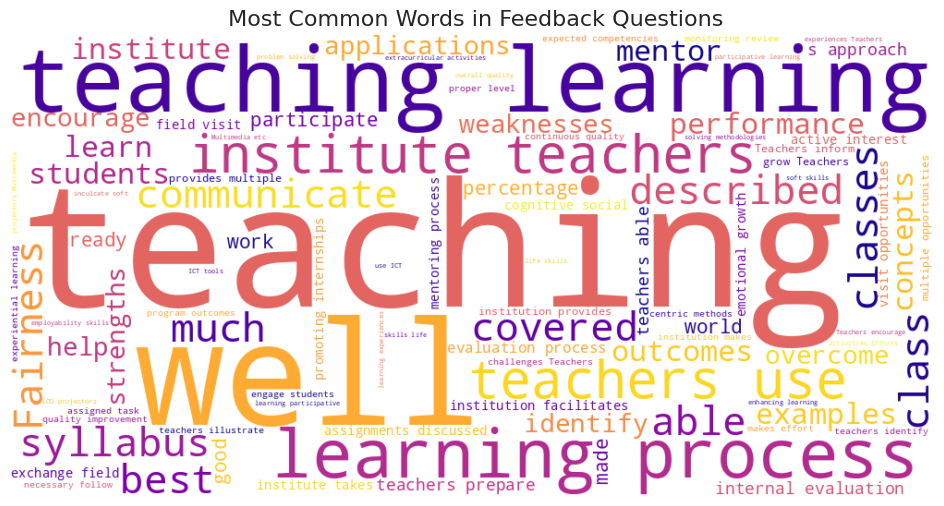

In [14]:
# ---------------------------
#  Word Cloud of Common Phrases / Questions
# ---------------------------

from wordcloud import WordCloud, STOPWORDS

# Combine all text from the 'Questions' column
if 'Questions' in df.columns:
    text_data = " ".join(str(i) for i in df['Questions'])

    # Optional: Add extra stopwords to remove common irrelevant words
    custom_stopwords = set(STOPWORDS)
    custom_stopwords.update(["student", "feedback", "course", "subject", "teacher", "faculty"])

    # Create and display the word cloud
    plt.figure(figsize=(12,6))
    wordcloud = WordCloud(width=1000, height=500,
                          background_color='white',
                          colormap='plasma',
                          stopwords=custom_stopwords,
                          max_words=100).generate(text_data)

    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(" Most Common Words in Feedback Questions", fontsize=16)
    plt.show()
else:
    print("Questions' column not found in dataset.")


##7.Sentiment Analysis Using VADER

This cell applies the **VADER (Valence Aware Dictionary and sEntiment Reasoner)** model to determine the emotional tone of each question or feedback statement.
It assigns each entry a **compound sentiment score** ranging from -1 (negative) to +1 (positive) and then categorizes them into *Positive*, *Neutral*, or *Negative* labels, helping identify the overall sentiment trends in the feedback.


In [10]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Apply sentiment scoring
df['sentiment'] = df['Questions'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Classify sentiment
df['sentiment_label'] = df['sentiment'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral')
)

df[['Questions', 'sentiment', 'sentiment_label']].head(10)


,Questions,sentiment,sentiment_label
0,How much of the syllabus was covered in the cl...,0.0000,Neutral
1,How well did the teachers prepare for the clas...,0.2732,Positive
2,How well were the teachers able to communicate?,0.2732,Positive
3,The teachers approach to teaching can best be...,0.6369,Positive
4,Fairness of the internal evaluation process by...,0.0000,Neutral
5,Was your performance in assignments discussed ...,0.0000,Neutral
6,The institute takes an active interest in prom...,0.8689,Positive
7,The teaching and mentoring process in your ins...,0.4939,Positive
8,The institution provides multiple opportunitie...,0.3818,Positive
9,Teachers inform you about your expected compet...,0.0000,Neutral


##8. Visualizing Sentiment Distribution

This cell creates a count plot showing how many feedback entries fall into each sentiment category—Positive, Neutral, or Negative.
Using bright, contrasting colors, it provides a clear visual summary of the overall tone of student feedback, helping you quickly gauge satisfaction and emotional trends across responses.


/tmp/ipython-input-2591030636.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment_label', palette=['#EF5350', '#FFEE58', '#66BB6A'])
/tmp/ipython-input-2591030636.py:2: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.countplot(data=df, x='sentiment_label', palette=['#EF5350', '#FFEE58', '#66BB6A'])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128483 (\N{SPEAKING HEAD IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


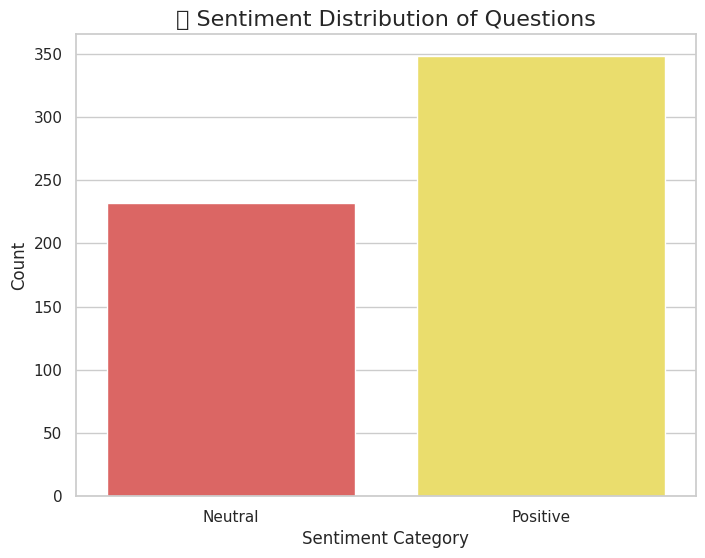

In [11]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='sentiment_label', palette=['#EF5350', '#FFEE58', '#66BB6A'])
plt.title("🗣️ Sentiment Distribution of Questions", fontsize=16)
plt.xlabel("Sentiment Category")
plt.ylabel("Count")
plt.show()


##9.Sentiment vs. Satisfaction Relationship

This cell compares the **sentiment categories** (Positive, Neutral, Negative) with the **average satisfaction scores** from the dataset.
The boxplot visually shows how sentiment aligns with numeric ratings — for instance, whether positive comments tend to correspond to higher satisfaction percentages — helping reveal the emotional influence behind the feedback data.


/tmp/ipython-input-892701912.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment_label', y='Average/ Percentage',
/tmp/ipython-input-892701912.py:2: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(data=df, x='sentiment_label', y='Average/ Percentage',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


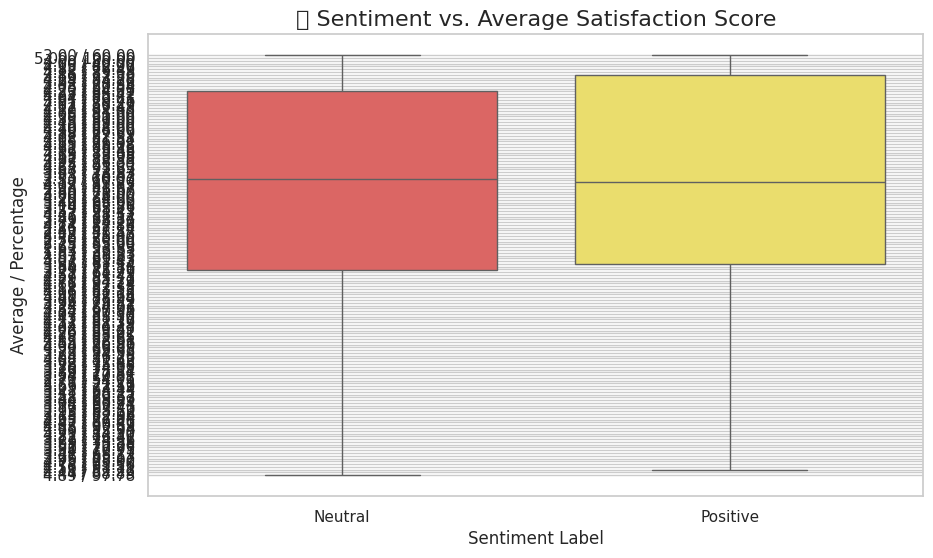

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='sentiment_label', y='Average/ Percentage',
            palette=['#EF5350', '#FFEE58', '#66BB6A'])
plt.title("📈 Sentiment vs. Average Satisfaction Score", fontsize=16)
plt.xlabel("Sentiment Label")
plt.ylabel("Average / Percentage")
plt.show()


##Sentiment Analysis Summary

The sentiment distribution indicates that **most feedback statements are positive**, followed by a substantial portion of neutral sentiments. Negative sentiments appear minimal, suggesting that students generally express satisfaction with their course experiences and event organization. The predominance of positive tones reflects effective teaching methods, engaging content, or good event execution.

Meanwhile, the correlation heatmap of rating metrics shows **moderate to strong relationships** between the different satisfaction measures (Weightage 3–5), implying that when students rate one aspect highly, they tend to rate others positively too. This consistency reinforces the overall positive perception of the learning or event environment.

## Recommendations for Organizers

1. **Sustain Strengths:** Maintain the aspects that drive positive sentiment — such as engaging instructors, clear course structure, or well-planned events.
2. **Address Neutral Areas:** Investigate why some responses are neutral — these may signal areas where experiences are satisfactory but not outstanding. Small improvements (e.g., better feedback systems or more interactive activities) could boost satisfaction further.
3. **Encourage Feedback Diversity:** Add open-ended questions to capture deeper qualitative feedback on what specifically works well or needs enhancement.
4. **Monitor Correlations:** Since higher ratings tend to cluster, organizers should focus on holistic improvement — enhancing one element (like communication or support) may uplift overall satisfaction.
5. **Continuous Review:** Conduct follow-up surveys after implementing changes to track sentiment shifts over time and validate improvements.
